# Strawberry Detector: Baseline → Fine-Tuned YOLO (One-Stop Showcase)

This notebook presents the full story in one place:
- Baseline: OpenCV template matching counts
- Before: YOLO11s pretrained metrics on our dataset
- Train: Fine-tune YOLO11s on our labels
- After: Validation metrics and count accuracy
- Visual comparisons and an autogenerated report


In [1]:
import os, sys, json
from typing import List, Tuple, Dict, Any, Optional, Union
import cv2
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO
sys.path.append(os.path.abspath('src'))
from baseline import create_template, run_baseline
from yolo_utils import split_and_prepare, parse_annotations
from train_and_infer import train_model, run_inference
from IPython.display import display, Markdown



In [2]:
ROOT: str = os.path.abspath(os.getcwd())
XML_PATH: str = os.path.join(ROOT, 'dataset', 'annotations.xml')
IMAGES_DIR: str = os.path.join(ROOT, 'dataset', 'images')
YOLO_DATASET_DIR: str = os.path.join(ROOT, 'strawberry_dataset')
VAL_IMAGES: str = os.path.join(YOLO_DATASET_DIR, 'images', 'val')
VAL_LABELS: str = os.path.join(YOLO_DATASET_DIR, 'labels', 'val')
OUTPUT_DIR: str = os.path.join(ROOT, 'output')
TEMPLATE_PATH: str = os.path.join(ROOT, 'template', 'template.png')
PRETRAINED_MODEL: str = 'yolo11s.pt'
FINETUNED_WEIGHTS: str = os.path.join(OUTPUT_DIR, 'train', 'weights', 'best.pt')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.dirname(TEMPLATE_PATH), exist_ok=True)
if not os.path.exists(os.path.join(YOLO_DATASET_DIR, 'data.yaml')) and os.path.exists(XML_PATH) and os.path.isdir(IMAGES_DIR):
    split_and_prepare(XML_PATH, IMAGES_DIR, YOLO_DATASET_DIR)
DATA_YAML: Optional[str] = os.path.join(YOLO_DATASET_DIR, 'data.yaml') if os.path.exists(os.path.join(YOLO_DATASET_DIR, 'data.yaml')) else None
device: Union[str, int] = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
print('Data YAML:', DATA_YAML)


Device: cuda:0
Data YAML: c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\data.yaml


## Baseline: OpenCV Template Matching

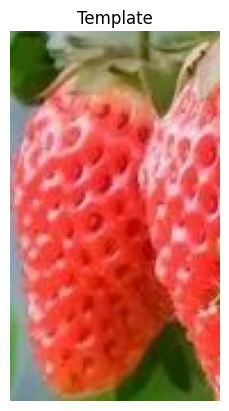

Template exists: True c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\template\template.png


In [3]:
if os.path.exists(XML_PATH) and os.path.isdir(IMAGES_DIR) and not os.path.exists(TEMPLATE_PATH):
    create_template(XML_PATH, IMAGES_DIR, TEMPLATE_PATH)
if os.path.exists(TEMPLATE_PATH):
    timg = cv2.imread(TEMPLATE_PATH)
    if timg is not None:
        plt.imshow(cv2.cvtColor(timg, cv2.COLOR_BGR2RGB))
        plt.title('Template')
        plt.axis('off')
        plt.show()
print('Template exists:', os.path.exists(TEMPLATE_PATH), TEMPLATE_PATH)


2025-08-30 17:31:58,240 - INFO - Baseline detection complete - 0 items found.


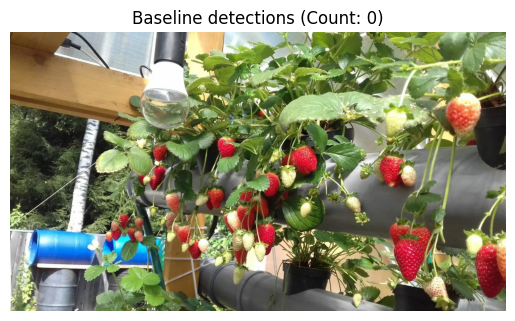

Baseline count (sample): 0


In [4]:
sample_img: Optional[str] = None
if os.path.isdir(VAL_IMAGES):
    names = [n for n in sorted(os.listdir(VAL_IMAGES)) if n.lower().endswith(('.png','.jpg','.jpeg'))]
    sample_img = os.path.join(VAL_IMAGES, names[0]) if names else None
baseline_out: str = os.path.join(OUTPUT_DIR, 'baseline_sample.jpg')
baseline_count: int = 0
if sample_img and os.path.exists(TEMPLATE_PATH):
    baseline_count = run_baseline(sample_img, TEMPLATE_PATH, baseline_out, threshold=0.8)
    if os.path.exists(baseline_out):
        img = cv2.imread(baseline_out)
        if img is not None:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f'Baseline detections (Count: {baseline_count})')
            plt.axis('off')
            plt.show()
print('Baseline count (sample):', baseline_count)


## Before: YOLO11s Pretrained Validation Metrics

In [5]:
before_metrics: Dict[str, Any] = {}
if DATA_YAML and os.path.exists(DATA_YAML):
    try:
        m = YOLO(PRETRAINED_MODEL)
        res = m.val(data=DATA_YAML, imgsz=640, device=device, project=OUTPUT_DIR, name='val-pretrained', exist_ok=True)
        before_metrics = getattr(res, 'results_dict', {}) or {}
    except Exception as e:
        print('Pretrained val failed:', e)
        before_metrics = {}
before_metrics

Ultralytics 8.3.158  Python-3.12.9 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1125.3505.8 MB/s, size: 1554.5 KB)


val: Scanning C:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\labels\val.cache... 8 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.94it/s]


                   all          8         79          0          0          0          0
                person          8         79          0          0          0          0
Speed: 0.9ms preprocess, 20.3ms inference, 0.0ms loss, 26.0ms postprocess per image
Results saved to c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\output\val-pretrained


{'metrics/precision(B)': np.float64(0.0),
 'metrics/recall(B)': np.float64(0.0),
 'metrics/mAP50(B)': np.float64(0.0),
 'metrics/mAP50-95(B)': np.float64(0.0),
 'fitness': np.float64(0.0)}

## Train: Fine-Tune YOLO11s

In [6]:
if DATA_YAML and os.path.exists(DATA_YAML):
    print('Starting training')
    best_path: str = train_model(DATA_YAML, epochs=300, device=device)
    print('Best weights:', best_path)
else:
    print('Dataset missing')


Starting training
New https://pypi.org/project/ultralytics/8.3.189 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.158  Python-3.12.9 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, 

train: Scanning C:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\labels\train.cache... 32 images, 0 backgrounds, 0 corrupt: 100%|██████████| 32/32 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 1319.0305.6 MB/s, size: 1166.6 KB)


val: Scanning C:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\labels\val.cache... 8 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8/8 [00:00<?, ?it/s]


Plotting labels to output\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to output\train
Starting training for 300 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all          8         79      0.946      0.734      0.885      0.582
Speed: 1.3ms preprocess, 29.2ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to output\train
Ultralytics 8.3.158  Python-3.12.9 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2123.9706.2 MB/s, size: 1668.4 KB)


val: Scanning C:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\labels\val.cache... 8 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:07<00:00,  7.83s/it]


                   all          8         79      0.947      0.734      0.884      0.579
Speed: 3.2ms preprocess, 46.0ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to output\val


2025-08-30 17:51:26,329 - INFO - Validation metrics: {'metrics/precision(B)': np.float64(0.9466030779659758), 'metrics/recall(B)': np.float64(0.7341772151898734), 'metrics/mAP50(B)': np.float64(0.8842871265592139), 'metrics/mAP50-95(B)': np.float64(0.5794882785671164), 'fitness': np.float64(0.6099681633663261)}
2025-08-30 17:51:26,329 - INFO - Training complete. Best weights at: output\train\weights\best.pt


Best weights: output\train\weights\best.pt


### Training Plots

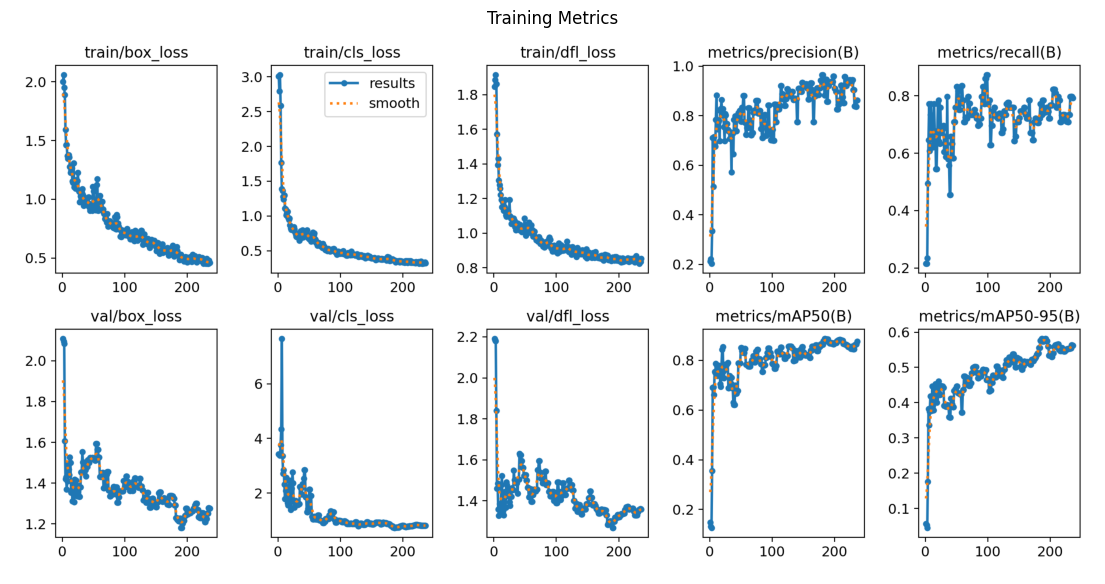

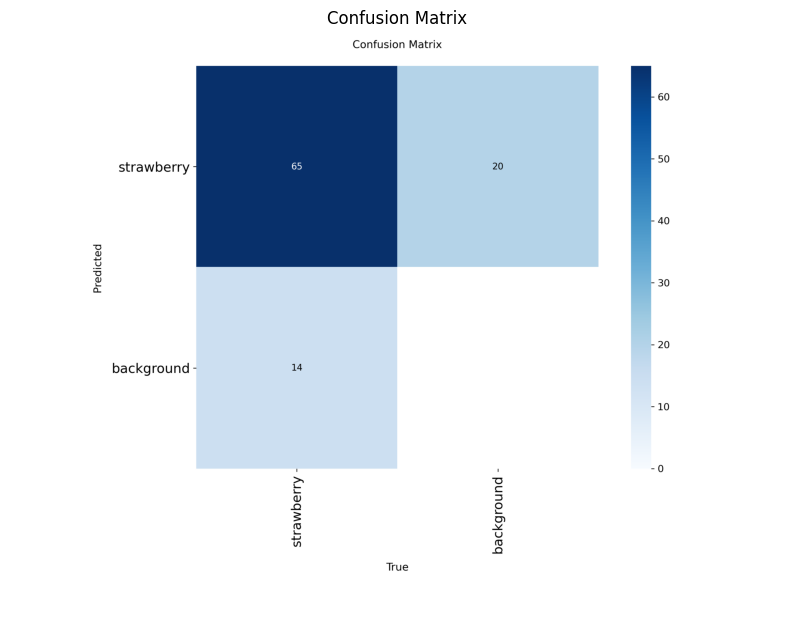

In [7]:
results_plot_path: str = os.path.join(OUTPUT_DIR, 'train', 'results.png')
confusion_matrix_path: str = os.path.join(OUTPUT_DIR, 'train', 'confusion_matrix.png')
if os.path.exists(results_plot_path):
    img = cv2.imread(results_plot_path)
    if img is not None:
        plt.figure(figsize=(14,10))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title('Training Metrics')
        plt.axis('off')
        plt.show()
if os.path.exists(confusion_matrix_path):
    img = cv2.imread(confusion_matrix_path)
    if img is not None:
        plt.figure(figsize=(10,8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title('Confusion Matrix')
        plt.axis('off')
        plt.show()


## After: Fine-Tuned Validation Metrics

In [8]:
after_metrics: Dict[str, Any] = {}
if os.path.exists(FINETUNED_WEIGHTS) and DATA_YAML and os.path.exists(DATA_YAML):
    model_after = YOLO(FINETUNED_WEIGHTS)
    val_res = model_after.val(data=DATA_YAML, imgsz=640, device=device, project=OUTPUT_DIR, name='val-report', exist_ok=True)
    after_metrics = getattr(val_res, 'results_dict', {}) or {}
after_metrics


Ultralytics 8.3.158  Python-3.12.9 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1953.6738.6 MB/s, size: 1455.5 KB)


val: Scanning C:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\labels\val.cache... 8 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:04<00:00,  4.80s/it]


                   all          8         79      0.947      0.734      0.884      0.579
Speed: 2.7ms preprocess, 39.7ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\output\val-report


{'metrics/precision(B)': np.float64(0.9466030779659758),
 'metrics/recall(B)': np.float64(0.7341772151898734),
 'metrics/mAP50(B)': np.float64(0.8842871265592139),
 'metrics/mAP50-95(B)': np.float64(0.5794882785671164),
 'fitness': np.float64(0.6099681633663261)}

## Before vs After: Count Accuracy Tables

In [9]:
from typing import Iterable
def list_images(dir_path: str) -> List[str]:
    exts = ('.png', '.jpg', '.jpeg')
    if not os.path.isdir(dir_path):
        return []
    return [os.path.join(dir_path, n) for n in sorted(os.listdir(dir_path)) if n.lower().endswith(exts)]
def read_gt_count(labels_dir: str, image_path: str) -> int:
    base = os.path.splitext(os.path.basename(image_path))[0]
    lbl_path = os.path.join(labels_dir, f'{base}.txt')
    if not os.path.exists(lbl_path):
        return 0
    with open(lbl_path, 'r', encoding='utf-8') as f:
        return sum(1 for line in f if line.strip())
def baseline_predict_count(image_path: str, template_path: str, out_dir: str, threshold: float = 0.8) -> int:
    os.makedirs(out_dir, exist_ok=True)
    out_img = os.path.join(out_dir, os.path.basename(image_path).rsplit('.', 1)[0] + '.jpg')
    return run_baseline(image_path, template_path, out_img, threshold=threshold)
def yolo_predict_count(model: YOLO, image_path: str, conf: float = 0.5, device: Union[str, int] = 'cpu') -> int:
    r = model.predict(source=image_path, conf=conf, save=False, device=device)
    if not r:
        return 0
    b = getattr(r[0], 'boxes', None)
    if b is None:
        return 0
    cls_ids = getattr(b, 'cls', None)
    if cls_ids is None:
        return int(getattr(b, 'shape', [0])[0])
    return int(cls_ids.shape[0])
def to_markdown_table(rows: List[Tuple[str, int, int, int]]) -> Markdown:
    lines = ['| filename | gt_count | pred_count | diff |', '|---|---:|---:|---:|']
    for name, gt, pr, diff in rows:
        lines.append(f'| {name} | {gt} | {pr} | {diff} |')
    return Markdown('\n'.join(lines))
def compute_mae_mape(rows: List[Tuple[str, int, int, int]]) -> Tuple[float, float]:
    if not rows:
        return 0.0, 0.0
    abs_err = [abs(diff) for (_, _, _, diff) in rows]
    mae = float(sum(abs_err) / len(abs_err)) if abs_err else 0.0
    ape: List[float] = []
    for (_, gt, pr, _) in rows:
        if gt > 0:
            ape.append(abs((pr - gt) / gt) * 100.0)
    mape = float(sum(ape) / len(ape)) if ape else 0.0
    return mae, mape


In [10]:
rows_baseline: List[Tuple[str, int, int, int]] = []
val_imgs: List[str] = list_images(VAL_IMAGES)
BASELINE_PRED_DIR: str = os.path.join(OUTPUT_DIR, 'baseline_eval')
for img in val_imgs[:10]:
    gt = read_gt_count(VAL_LABELS, img)
    pr = baseline_predict_count(img, TEMPLATE_PATH, BASELINE_PRED_DIR, threshold=0.8)
    rows_baseline.append((os.path.basename(img), gt, pr, pr - gt))
display(to_markdown_table(rows_baseline))
b_mae, b_mape = compute_mae_mape(rows_baseline)
print('Baseline MAE:', f'{b_mae:.4f}', 'MAPE:', f'{b_mape:.2f}%')


2025-08-30 17:51:36,172 - INFO - Baseline detection complete - 0 items found.
2025-08-30 17:51:36,200 - INFO - Baseline detection complete - 0 items found.
2025-08-30 17:51:36,403 - INFO - Baseline detection complete - 0 items found.
2025-08-30 17:51:36,457 - INFO - Baseline detection complete - 0 items found.
2025-08-30 17:51:36,607 - INFO - Baseline detection complete - 0 items found.
2025-08-30 17:51:36,683 - INFO - Baseline detection complete - 0 items found.
2025-08-30 17:51:36,716 - INFO - Baseline detection complete - 0 items found.
2025-08-30 17:51:36,746 - INFO - Baseline detection complete - 0 items found.


| filename | gt_count | pred_count | diff |
|---|---:|---:|---:|
| 1.png | 24 | 0 | -24 |
| 13.png | 9 | 0 | -9 |
| 14.png | 12 | 0 | -12 |
| 15.png | 7 | 0 | -7 |
| 16.png | 9 | 0 | -9 |
| 21.png | 9 | 0 | -9 |
| 22.png | 4 | 0 | -4 |
| 24.png | 5 | 0 | -5 |

Baseline MAE: 9.8750 MAPE: 100.00%


In [11]:
rows_after: List[Tuple[str, int, int, int]] = []
if os.path.exists(FINETUNED_WEIGHTS):
    model_for_pred = YOLO(FINETUNED_WEIGHTS)
    for img in val_imgs[:10]:
        gt = read_gt_count(VAL_LABELS, img)
        pr = yolo_predict_count(model_for_pred, img, conf=0.5, device=device)
        rows_after.append((os.path.basename(img), gt, pr, pr - gt))
display(to_markdown_table(rows_after))
a_mae, a_mape = compute_mae_mape(rows_after)
print('YOLO MAE:', f'{a_mae:.4f}', 'MAPE:', f'{a_mape:.2f}%')



image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\1.png: 384x640 18 strawberrys, 86.8ms
Speed: 4.6ms preprocess, 86.8ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\13.png: 512x640 10 strawberrys, 85.2ms
Speed: 1.9ms preprocess, 85.2ms inference, 2.3ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\14.png: 480x640 11 strawberrys, 73.1ms
Speed: 2.3ms preprocess, 73.1ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\15.png: 480x640 6 strawberrys, 13.2ms
Speed: 2.1ms preprocess, 13.2ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 c:\Users\wbrya\OneD

| filename | gt_count | pred_count | diff |
|---|---:|---:|---:|
| 1.png | 24 | 18 | -6 |
| 13.png | 9 | 10 | 1 |
| 14.png | 12 | 11 | -1 |
| 15.png | 7 | 6 | -1 |
| 16.png | 9 | 9 | 0 |
| 21.png | 9 | 9 | 0 |
| 22.png | 4 | 4 | 0 |
| 24.png | 5 | 7 | 2 |

YOLO MAE: 1.3750 MAPE: 12.34%


## Visual Comparison on One Image


image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\1.png: 384x640 8 apples, 3 potted plants, 22.1ms
Speed: 2.0ms preprocess, 22.1ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\output\pretrained_preds\predictions


2025-08-30 17:51:38,494 - INFO - Inference complete. Found 0 strawberry detections.



image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\1.png: 384x640 18 strawberrys, 14.4ms
Speed: 2.2ms preprocess, 14.4ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\output\finetuned_preds\predictions


2025-08-30 17:51:38,933 - INFO - Inference complete. Found 18 strawberry detections.


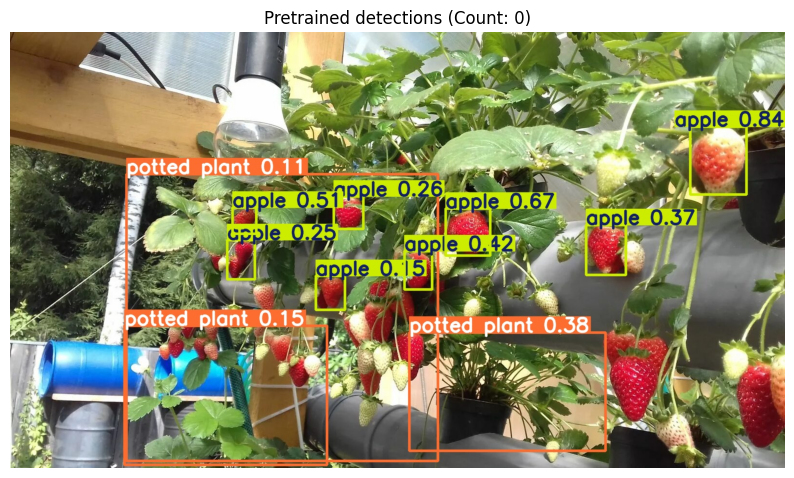

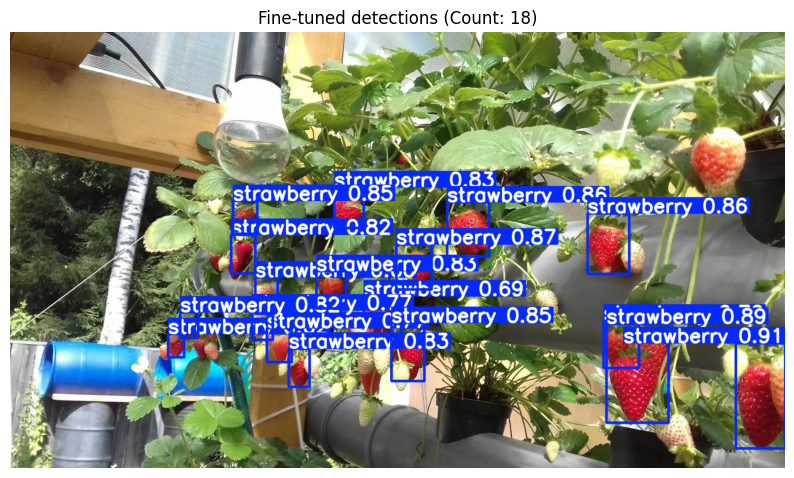

In [12]:
vis_img: Optional[str] = None
if os.path.isdir(VAL_IMAGES):
    cands = [n for n in sorted(os.listdir(VAL_IMAGES)) if n.lower().endswith(('.png','.jpg','.jpeg'))]
    vis_img = os.path.join(VAL_IMAGES, cands[0]) if cands else None
PRETRAINED_OUT: str = os.path.join(OUTPUT_DIR, 'pretrained_preds')
FINETUNED_OUT: str = os.path.join(OUTPUT_DIR, 'finetuned_preds')
if vis_img:
    pc = run_inference(PRETRAINED_MODEL, vis_img, PRETRAINED_OUT, conf=0.10, device=device)
    fc = run_inference(FINETUNED_WEIGHTS if os.path.exists(FINETUNED_WEIGHTS) else PRETRAINED_MODEL, vis_img, FINETUNED_OUT, conf=0.60, device=device)
    p_name = os.path.basename(vis_img).rsplit('.',1)[0] + '.jpg'
    p_path = os.path.join(PRETRAINED_OUT, 'predictions', p_name)
    f_path = os.path.join(FINETUNED_OUT, 'predictions', p_name)
    if os.path.exists(p_path):
        img = cv2.imread(p_path)
        if img is not None:
            plt.figure(figsize=(10,8))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f'Pretrained detections (Count: {pc})')
            plt.axis('off')
            plt.show()
    if os.path.exists(f_path):
        img = cv2.imread(f_path)
        if img is not None:
            plt.figure(figsize=(10,8))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f'Fine-tuned detections (Count: {fc})')
            plt.axis('off')
            plt.show()


## Autogenerated Report

In [13]:
report_out: str = os.path.join(OUTPUT_DIR, 'report_metrics.md')
os.makedirs(os.path.dirname(report_out), exist_ok=True)
with open(report_out, 'w', encoding='utf-8') as f:
    f.write('### Autogenerated results\n\n')
    f.write('Before (YOLO11s pretrained) – validation metrics:\n\n')
    f.write('```json\n')
    f.write(json.dumps(before_metrics, indent=2))
    f.write('\n```\n\n')
    f.write('After (YOLO11s finetuned) – validation metrics:\n\n')
    f.write('```json\n')
    f.write(json.dumps(after_metrics, indent=2))
    f.write('\n```\n\n')
    f.write('Before (OpenCV baseline) – count accuracy:\n\n')
    f.write(str(to_markdown_table(rows_baseline)))
    f.write('After (YOLO11s finetuned) – count accuracy:\n\n')
    f.write(str(to_markdown_table(rows_after)))
print(report_out)


c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\output\report_metrics.md


## Conclusions
- Baseline struggles on scale/appearance changes.
- Pretrained YOLO provides a neutral baseline for metrics.
- Fine-tuning learns the strawberry class and improves mAP and counts.
- Report persisted to `output/report_metrics.md`.
